#  Аналіз ринку ноутбуків на базі 3 магазинів (Foxtrot. Telemart. Brain)

# Підготовка даних

In [119]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

## Завантажуємо дані

In [120]:
foxtrot = pd.read_csv(r"D:\projects\Mega-laptop-parser\data\foxtrot_data.csv")
brain = pd.read_csv(r"D:\projects\Mega-laptop-parser\data\brain_data.csv")
telemart = pd.read_csv(r"D:\projects\Mega-laptop-parser\data\telemart_data.csv")
cpu_rating = pd.read_csv(r"D:\projects\Mega-laptop-parser\data\technical_city_cpu.csv")
gpu_rating = pd.read_csv(r"D:\projects\Mega-laptop-parser\data\technical_city_gpu.csv")

In [121]:
foxtrot = pd.DataFrame(foxtrot)
brain = pd.DataFrame(brain)
telemart = pd.DataFrame(telemart)
cpurating = pd.DataFrame(cpu_rating)
gpurating = pd.DataFrame(gpu_rating)

### Стандартизація датафрейму

#### Foxtrot

In [122]:
foxtrot.info()

<class 'pandas.DataFrame'>
RangeIndex: 840 entries, 0 to 839
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   full_name     840 non-null    str    
 1   price         840 non-null    float64
 2   product_code  840 non-null    float64
 3   shop          840 non-null    str    
 4   product_url   840 non-null    str    
 5   cpu           840 non-null    str    
 6   gpu           835 non-null    str    
 7   other         840 non-null    str    
dtypes: float64(2), str(6)
memory usage: 52.6 KB


In [123]:
def full_name(name: str, l: list):
    if not isinstance(name, str):
        return name
    
    name = name.strip()
    pattern = rf"\b{re.escape(name)}\b"

    # Шукаємо повнішу назву у рейтингу
    for full_name in l:
        if isinstance(full_name, str) and re.search(pattern.lower(), full_name.lower()):
            return full_name
    
    return name

In [124]:
cpulist = cpu_rating['full_name'].tolist()
foxtrot['cpu'] = foxtrot['cpu'].apply(lambda x: full_name(x, cpulist))
foxtrot['product_code'] = foxtrot['product_code'].astype(int).astype(str)
foxtrot.info()

<class 'pandas.DataFrame'>
RangeIndex: 840 entries, 0 to 839
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   full_name     840 non-null    str    
 1   price         840 non-null    float64
 2   product_code  840 non-null    str    
 3   shop          840 non-null    str    
 4   product_url   840 non-null    str    
 5   cpu           840 non-null    str    
 6   gpu           835 non-null    str    
 7   other         840 non-null    str    
dtypes: float64(1), str(7)
memory usage: 52.6 KB


#### Brain

In [125]:
brain.info()

<class 'pandas.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   full_name     480 non-null    str    
 1   price         480 non-null    float64
 2   product_code  480 non-null    str    
 3   shop          480 non-null    str    
 4   product_url   480 non-null    str    
 5   cpu           480 non-null    str    
 6   gpu           480 non-null    str    
 7   other         480 non-null    str    
dtypes: float64(1), str(7)
memory usage: 30.1 KB


#### Telemart

In [126]:
telemart.info()
telemart['product_code'] = telemart['product_code'].astype(int).astype(str)

<class 'pandas.DataFrame'>
RangeIndex: 735 entries, 0 to 734
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   full_name     735 non-null    str    
 1   price         735 non-null    float64
 2   product_code  735 non-null    float64
 3   shop          735 non-null    str    
 4   product_url   735 non-null    str    
 5   cpu           735 non-null    str    
 6   gpu           735 non-null    str    
 7   other         735 non-null    str    
dtypes: float64(2), str(6)
memory usage: 46.1 KB


#### CPU & GPU

In [127]:
cpu_rating = cpu_rating.drop('name', axis=1)
gpu_rating = gpu_rating.drop('name', axis=1)

In [128]:
cpu_rating = cpu_rating[cpu_rating['full_name'].notna()]
gpu_rating = gpu_rating[gpu_rating['full_name'].notna()]

In [129]:
cpu_rating.info()

<class 'pandas.DataFrame'>
Index: 3725 entries, 0 to 3729
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   rate         3725 non-null   int64  
 1   full_name    3725 non-null   str    
 2   device_type  3725 non-null   str    
 3   performance  3725 non-null   float64
 4   year         3596 non-null   float64
 5   tdp          3712 non-null   float64
 6   cores        3667 non-null   float64
 7   threads      3667 non-null   float64
dtypes: float64(5), int64(1), str(2)
memory usage: 261.9 KB


### Створення універсального датафрейму

#### Універсальний датафрейм

In [130]:
all_shop = pd.concat([brain, telemart, foxtrot])
all_shop.info()

<class 'pandas.DataFrame'>
Index: 2055 entries, 0 to 839
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   full_name     2055 non-null   str    
 1   price         2055 non-null   float64
 2   product_code  2055 non-null   str    
 3   shop          2055 non-null   str    
 4   product_url   2055 non-null   str    
 5   cpu           2055 non-null   str    
 6   gpu           2050 non-null   str    
 7   other         2055 non-null   str    
dtypes: float64(1), str(7)
memory usage: 144.5 KB


#### Чистка та стандартизація

In [131]:
def clean_cpu(name: str):
    name = str(name)
    name = name.strip()                    # прибирає пробіли з обох боків
    name = ' '.join(name.split())          # прибирає всі множинні пробіли
    name = name.replace('\xa0', ' ')       # нерозривний пробіл (найчастіша проблема)
    name = name.replace('\u200b', '')      # zero-width space
    if not isinstance(name, str):
        return name
    if 'Intel Core Ultra' in name:
        return name.replace('-', " ")
    return name


all_shop['cpu'] = all_shop['cpu'].str.replace(r"\s\(.*?\)", "", regex=True).str.strip().apply(lambda x: clean_cpu(x))

In [132]:
def clean_gpu(name):
    if not isinstance(name, str):
        return name
    if "AMD" in name:
        name = re.sub(r"\bGraphics\b", "", name).strip()
    return re.sub(r"\s+", " ", name)

gpulist = gpu_rating['full_name'].tolist()
all_shop['gpu'] = all_shop['gpu'].fillna("").apply(lambda x: full_name(x, gpulist)).apply(lambda x: clean_gpu(x))

#### Завантаження унікальних видів CPU & GPU у окемений файл 

In [133]:
all_shop['cpu'].drop_duplicates().sort_values().to_csv("data/cpu_uniqe.csv", index=False, header=False)
all_shop['gpu'].drop_duplicates().sort_values().to_csv("data/gpu_uniqe.csv", index=False, header=False)
cpu_rating['full_name'].drop_duplicates().sort_values().to_csv("data/tcpu.csv", index=False, header=False)
gpu_rating['full_name'].drop_duplicates().sort_values().to_csv("data/tgpu.csv", index=False, header=False)

#### Створення універсального датафрейму та оптимізація назв колонок

In [134]:
laptop_rating = pd.merge(left=all_shop, right=cpu_rating, how="left", left_on="cpu", right_on="full_name", validate="m:1")
laptop_rating = pd.merge(left=laptop_rating, right=gpu_rating, how="left", left_on="gpu", right_on="full_name", suffixes=['_cpu', '_gpu'], validate="m:1")

In [135]:
laptop_rating = laptop_rating.rename(columns={
    'full_name':'gpu_name',
    'full_name_y':'cpu_name',
    'full_name_x': 'laptop_name',
    'rate_cpu': 'cpu_rating',
    'rate_gpu': 'gpu_rating'
    })
laptop_rating = laptop_rating.drop_duplicates()
laptop_rating.info()

<class 'pandas.DataFrame'>
Index: 2033 entries, 0 to 2054
Data columns (total 23 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   laptop_name      2033 non-null   str    
 1   price            2033 non-null   float64
 2   product_code     2033 non-null   str    
 3   shop             2033 non-null   str    
 4   product_url      2033 non-null   str    
 5   cpu              2033 non-null   str    
 6   gpu              2033 non-null   str    
 7   other            2033 non-null   str    
 8   cpu_rating       1882 non-null   float64
 9   cpu_name         1882 non-null   str    
 10  device_type_cpu  1882 non-null   str    
 11  performance_cpu  1882 non-null   float64
 12  year_cpu         1859 non-null   float64
 13  tdp_cpu          1880 non-null   float64
 14  cores            1875 non-null   float64
 15  threads          1875 non-null   float64
 16  gpu_rating       1757 non-null   float64
 17  gpu_name         1757 non-null

### Функція для отримання додактової характеристики

In [136]:
import ast
from typing import List

def get_spec(string: str, key: List[str] | str) -> str | None:
    try:
        d: dict = ast.literal_eval(string)
        if not isinstance(d, dict):
            return None
    except (ValueError, SyntaxError):
        return None
    
    keys = [key] if isinstance(key, str) else key

    for k in keys:
        if (res := d.get(k)) is not None:
            return res

    return None
    


### Фунція для отримання числового значення

In [137]:
import re

def get_numetric(string: str, first_only: bool = True) -> str | List[str]:
    m = re.findall(r'-?\d+', str(string))
    if len(m) <= 0:
        return string
    
    return m[0] if first_only else m

# Аналіз даних

#### Кількісь ноутбуків по магазинам

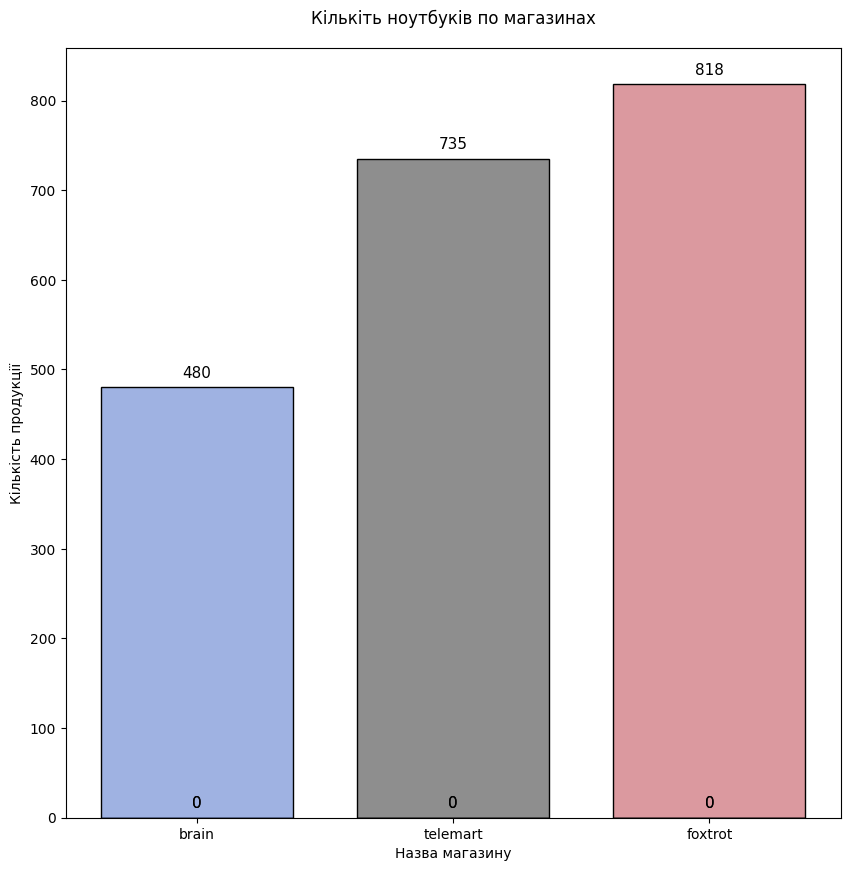

In [138]:
from typing import cast
import matplotlib.container as mcontainer


plt.figure(figsize=[10, 10])
ax = sns.histplot(
    x='shop', 
    data=laptop_rating, 
    hue='shop',
    shrink=0.75,
    palette='icefire',
    edgecolor='black',
    legend=False, 
    cbar=True
)


for container in ax.containers:
    ax.bar_label(
        cast(mcontainer.BarContainer, container),
        fontsize=11, 
        padding=5,
        label_type='edge', 
        fmt='%d'
    )
plt.title("Кількіть ноутбуків по магазинах", y=1.02)
plt.xlabel("Назва магазину")
plt.ylabel("Кількість продукції")
plt.show()

## Середній рейтинговий показник для ноутбука 

In [139]:
laptop_rating.to_csv('laptop_rating.csv', index=False)

### Очищення Nan значень

In [140]:
df = laptop_rating
df[['cpu_rating', 'gpu_rating']] = df[['cpu_rating', 'gpu_rating']].fillna(0)

#### Формула  (cou_rating + gpu_rating) // 2

In [141]:
def get_avg_perf_score(cpu_rating: int | None, gpu_rating: int | None) -> int | None:
        # Перевірка чи є взагалі якийсь рейтинг
        if cpu_rating is None and gpu_rating is None:
            return

        # Якщо є тільки GPU
        if cpu_rating is None and gpu_rating is not None:
            return int(gpu_rating) if gpu_rating else gpu_rating
        # Якщо є тільки CPU
        elif cpu_rating is not None and gpu_rating is None:
            return int(cpu_rating) if cpu_rating else cpu_rating
        # Якщо є CPU & GPU
        else:
             return (cpu_rating + gpu_rating) // 2  # type: ignore


In [142]:
v_get_score = np.vectorize(get_avg_perf_score)
df["avg_perf_score"] = v_get_score(df['cpu_rating'], df['gpu_rating'])

#### Графік розподілу ноутбуків за ціною

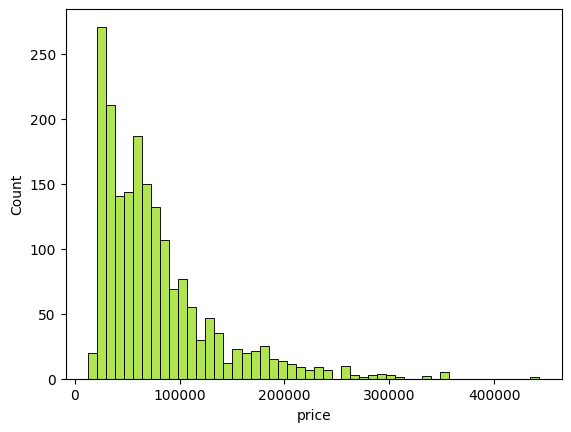

In [143]:
df = df.sort_values(by=['avg_perf_score', 'price'], ascending=True)
df = df[(df['cpu_name'].notna())].reset_index(drop=True)
sns.histplot(
    data=df,
    x='price',
    bins=50,
    color="#96DB15",
)
plt.show()

In [144]:
df[['cpu', 'cpu_name', "cpu_rating", 'gpu', 'gpu_name', 'gpu_rating', 'avg_perf_score', 'price']].sample(1)

,cpu,cpu_name,cpu_rating,gpu,gpu_name,gpu_rating,avg_perf_score,price
1653,Intel Core i3-1315U,Intel Core i3-1315U,1271.0,Intel UHD Graphics 730 (Rocket Lake),Intel UHD Graphics 730 (Rocket Lake),435.0,853.0,24099.0


#### Графік розподілу ноутбуків залежно від їх середньої продуктивності та ціни по магазинах

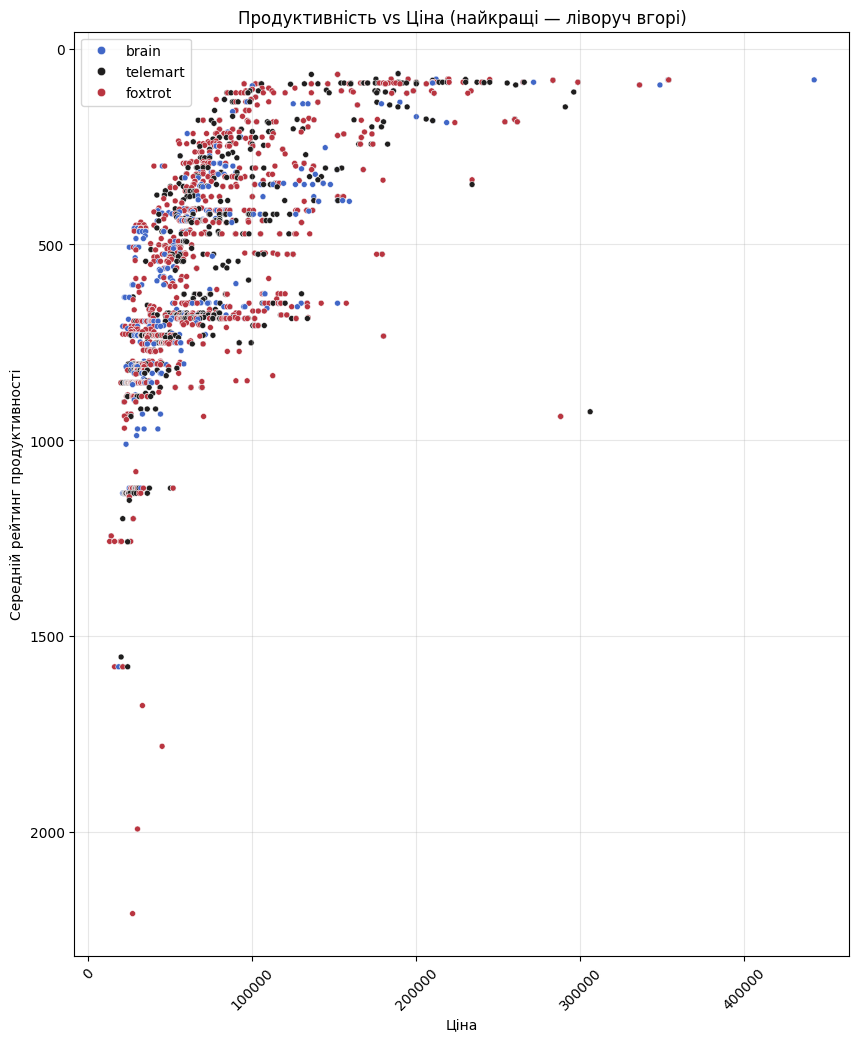

In [145]:
plt.figure(figsize=(10, 12))
ax = sns.scatterplot(
    data=df,
    x='price',
    y='avg_perf_score',
    hue='shop',
    size=1,
    palette='icefire'
)
plt.gca().invert_yaxis()

plt.title('Продуктивність vs Ціна (найкращі — ліворуч вгорі)')
plt.xlabel('Ціна')
plt.ylabel('Середній рейтинг продуктивності')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:-1], labels[:-1])

plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.show()

## Аналіз RAM у ноутбуках

In [146]:
df['RAM'] = df['other'] \
        .apply(lambda x: get_spec(x, ["Об'єм оперативної пам'яті", "Обсяг", "Об'єм ОЗП"])) \
        .apply(lambda x: get_numetric(x)).fillna(0).astype(int)

### Розподіл RAM у ноутбуках

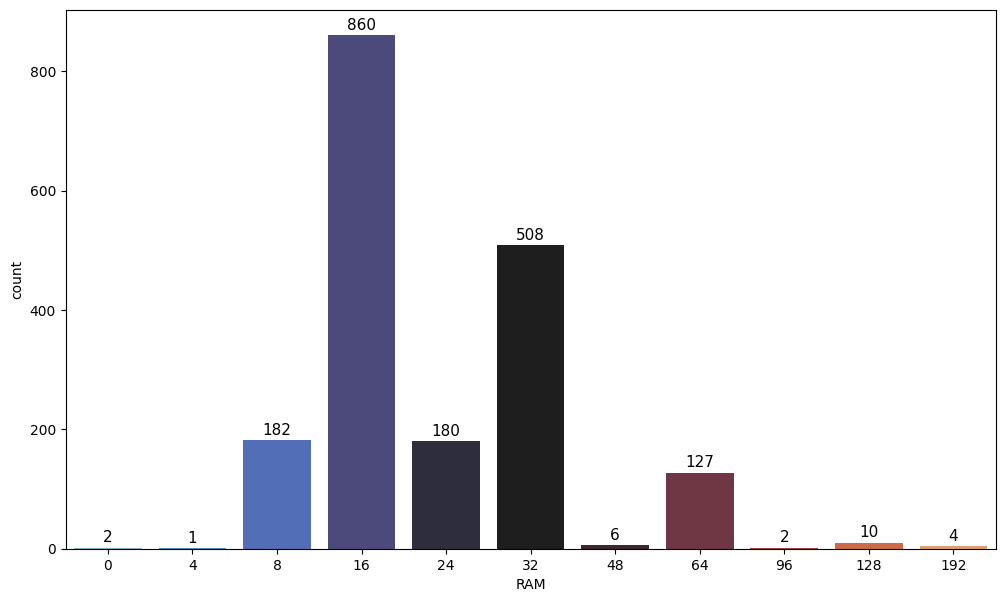

In [147]:
ram_order = sorted(df['RAM'].unique())
colors = sns.color_palette("icefire", len(ram_order))

plt.figure(figsize=(12, 7))
ax = sns.countplot(
    data=df,
    x='RAM',
    order=ram_order,
    hue='RAM',
    palette=colors,
    legend=False
)

for container in ax.containers:
    label = [
        int(v.get_height())
        if v.get_height() > 0 else ''
        for v in container
    ]

    ax.bar_label(
        cast(mcontainer.BarContainer, container),
        fontsize=11, 
        padding=2,
        label_type='edge', 
        label = label,
        fmt='%d'
    )

plt.show()


### Ціна за 1 гіг RAM

**Formula:**  (price / RAM)

In [148]:
df_ram = df[df['RAM']!=0]
df_ram['price_to_ram'] = round(df_ram['price'] / df_ram['RAM'], 2)

In [149]:
df_ram[['shop', 'product_code', 'laptop_name', 'price', 'RAM', 'price_to_ram', 'avg_perf_score']] \
    .sort_values(by=['price_to_ram', 'avg_perf_score', 'price'], ascending=[False, False, False]).head()

,shop,product_code,laptop_name,price,RAM,price_to_ram,avg_perf_score
1776,telemart,653806,Durabook Z14 Basic Black,305999.0,16,19124.94,927.0
1788,telemart,653805,Durabook Z14 Basic Black,287999.0,16,17999.94,939.0
1789,foxtrot,7008561,DURABOOK Z14 Basic Black,287999.0,16,17999.94,939.0
595,brain,U0929740,Dell XPS 16 9640,159156.0,16,9947.25,390.0
594,brain,U0999883,Dell XPS 14 9440,140474.0,16,8779.62,390.0


#### RAM на графіку ціна vs продуктивність

In [150]:
avg_score = df_ram.groupby('RAM')[['avg_perf_score', 'price']].mean().round(2)
avg_score = avg_score.reset_index()

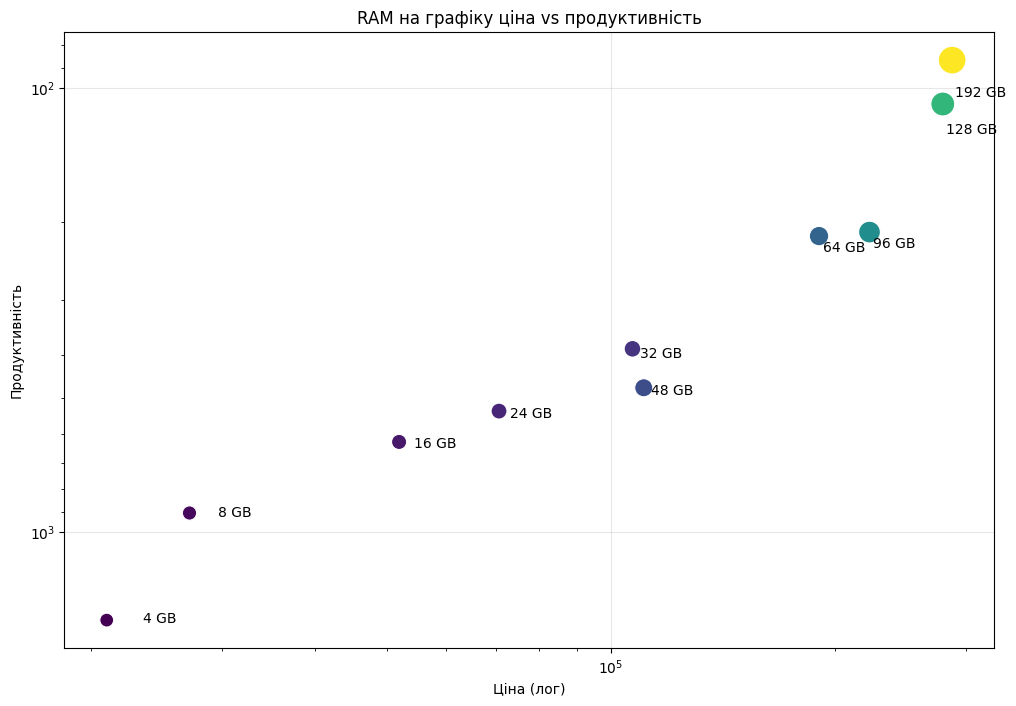

In [151]:
color = sns.color_palette('viridis', len(ram_order))

plt.figure(figsize=(12, 8))
sns.scatterplot(data=avg_score, x='price', y='avg_perf_score', 
                hue='RAM', size='RAM', sizes=(100, 400), palette='viridis', legend=False)

for i in range(len(avg_score)):
    plt.text(avg_score['price'].iloc[i]+2500, avg_score['avg_perf_score'].iloc[i]+18, 
             f"{avg_score['RAM'].iloc[i]} GB", fontsize=10)

plt.xscale('log')
plt.gca().invert_xaxis()
plt.title('RAM на графіку ціна vs продуктивність')
plt.xlabel('Ціна (лог)')
plt.ylabel('Продуктивність')
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.gca().invert_yaxis()
plt.gca().invert_xaxis()
plt.show()

## Роздільна здатність дисплею

#### Фунція для отримання кількості пікселів

In [152]:
def get_total_pixels(resolution: str) -> int | None:
    r = get_numetric(resolution, first_only=False)
    h, w = r[0], r[1]
    try:
        return int(h) * int(w)
    except ValueError:
        return None

In [153]:
df['resolution'] = df['other'] \
    .apply(lambda x: get_spec(x, ['Роздільна здатність', 'Роздільна здатність дисплея', 'Роздільність']))
df['total_pixels'] = df['resolution'].apply(lambda x: get_total_pixels(x)).astype(int)

In [154]:
resolution_dict = {
    1049088: "HD",
    2073600: "Full HD",
    2304000: "Full HD+",
    2457600: "Full HD+",
    2621440: "2K DCI",
    3136000: "WUX+",
    3657600: "WQHD",
    3686400: "WQHD",
    4096000: "WQXGA",
    4665600: "3K",
    5184000: "3K/Retina",
    5628000: "WQXGA+",
    8294400: "4K UHD",
    9216000: "4K UHD+"
}

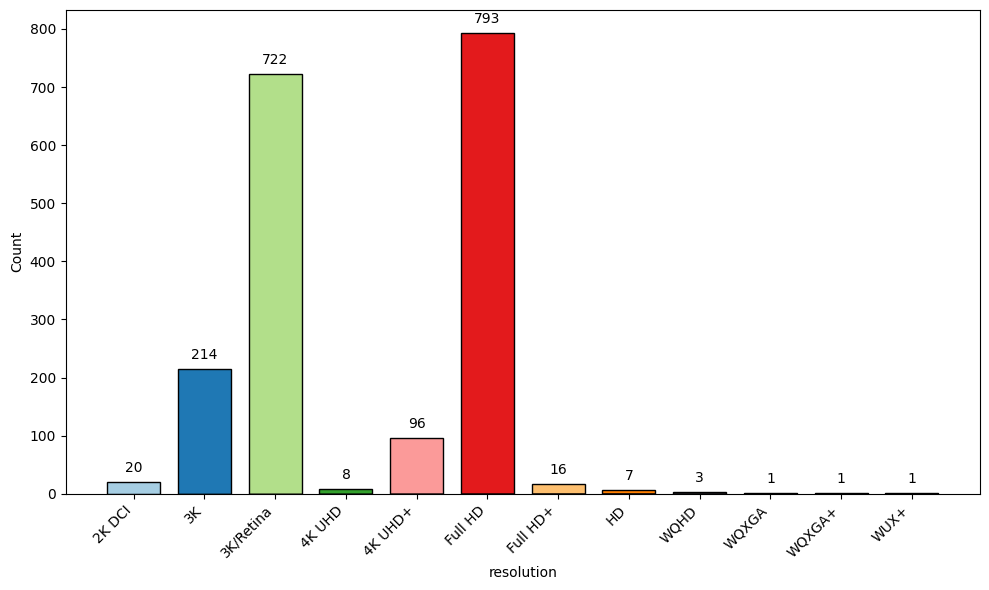

In [162]:
import matplotlib.ticker as ticker

df['resolution'] = df['total_pixels'].map(resolution_dict).fillna("Other")
res_order = sorted(df['resolution'].unique())
colors = sns.color_palette('Paired', len(res_order))

plt.figure(figsize=(10, 6))
ax = sns.histplot(
    data=df,
    x='resolution',
    hue='resolution',
    palette=colors,
    legend=False,
    edgecolor='black',
    shrink=0.75,
    alpha=1
)

# Прибираємо всі поточні мітки і встановлюємо вручну
ax.set_xticks(range(len(res_order)))
ax.set_xticklabels(res_order, rotation=45, ha='right')

for container in ax.containers:
    labels = [int(v.get_height()) if v.get_height() > 0 else '' for v in container]
    ax.bar_label(cast(mcontainer.BarContainer, container), labels=labels, fontsize=10, label_type='edge', padding=5)



plt.tight_layout()
plt.show()

#### Ціна за 1 pixel

**Formula:** price_to_pixel = round(price / total_pixels

In [156]:
df['price_to_pixel'] = round(df['price'] / df['total_pixels'], 3)

In [157]:
df['price_to_pixel'].sort_values(ascending=True).head()

1863    0.007
1864    0.007
1873    0.008
775     0.008
1866    0.008
Name: price_to_pixel, dtype: float64